# Assignment 2 - 2-Layer Neural Network for Tweet Sentiment Classification

## Setup & Processing

In [2]:
%load_ext autoreload
%autoreload 2

import pickle

import numpy as np

from assignment2 import (
  bce_forward,
  bce_forward_test,
  gradients,
  gradients_test,
  inference_2layers,
  inference_2layers_test,
  inference_layer,
  inference_layer_test,
  load_data,
  predict_nn,
  sigmoid,
  sigmoid_test,
  train_nn,
  train_nn_test,
  update_params,
  update_params_test,
)

[nltk_data] Downloading package twitter_samples to
[nltk_data]     /Users/ngochoang/nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ngochoang/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Q1.1 Sigmoid Inference

In [3]:
sigmoid_test()

sigmoid: tests OK.


## Q1.2 One Layer Inference

In [4]:
inference_layer_test()

inference_layer: tests OK.


## Q1.3 Two Layer Inference

In [5]:
inference_2layers_test()

inference_2layers: tests OK.


## Q1.4 BCE Loss

In [6]:
bce_forward_test()

bce_forward: tests OK.


## Q3.1 Gradients

In [7]:
gradients_test()

gradients: tests OK.


## Q4 Parameter Updates

In [8]:
update_params_test()

update_params: tests OK.


## Q5 Training the Neural Network

In [9]:
train_nn_test()

iter      0 | loss 0.9813
train_nn: tests OK. Please thoroughly test convergence


## Train on real Twitter data

In [10]:
W1, b1, W2, b2, Ls = train_nn(
  "twitter_data.pkl",
  hidden_layer_size=6,
  iters=int(1e5),
  lr=1e-5,
  batch=32,
)

iter      0 | loss 0.6942
iter   1000 | loss 0.6131
iter   2000 | loss 0.5391
iter   3000 | loss 0.4670
iter   4000 | loss 0.4339
iter   5000 | loss 0.3772
iter   6000 | loss 0.3470
iter   7000 | loss 0.3123
iter   8000 | loss 0.2892
iter   9000 | loss 0.2757
iter  10000 | loss 0.2607
iter  11000 | loss 0.2349
iter  12000 | loss 0.2140
iter  13000 | loss 0.2044
iter  14000 | loss 0.1969
iter  15000 | loss 0.1904
iter  16000 | loss 0.1698
iter  17000 | loss 0.1583


/Users/ngochoang/projects/cs6120-coursework/assignment2.py:28: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


iter  18000 | loss 0.1487
iter  19000 | loss 0.1456
iter  20000 | loss 0.1397
iter  21000 | loss 0.2505
iter  22000 | loss 0.1250
iter  23000 | loss 0.1225
iter  24000 | loss 0.1170
iter  25000 | loss 0.1125
iter  26000 | loss 0.1054
iter  27000 | loss 0.1029
iter  28000 | loss 0.0987
iter  29000 | loss 0.1014
iter  30000 | loss 0.0932
iter  31000 | loss 0.0965
iter  32000 | loss 0.0885
iter  33000 | loss 0.0919
iter  34000 | loss 0.0824
iter  35000 | loss 0.0960
iter  36000 | loss 0.1116
iter  37000 | loss 0.0745
iter  38000 | loss 0.0755
iter  39000 | loss 0.0711
iter  40000 | loss 0.0701
iter  41000 | loss 0.0716
iter  42000 | loss 0.0668
iter  43000 | loss 0.0645
iter  44000 | loss 0.0716
iter  45000 | loss 0.0671
iter  46000 | loss 0.0610
iter  47000 | loss 0.0597
iter  48000 | loss 0.0584
iter  49000 | loss 0.0578
iter  50000 | loss 0.0548
iter  51000 | loss 0.1137
iter  52000 | loss 0.0734
iter  53000 | loss 0.0534
iter  54000 | loss 0.0513
iter  55000 | loss 0.0523
iter  56000 

## Plot training loss

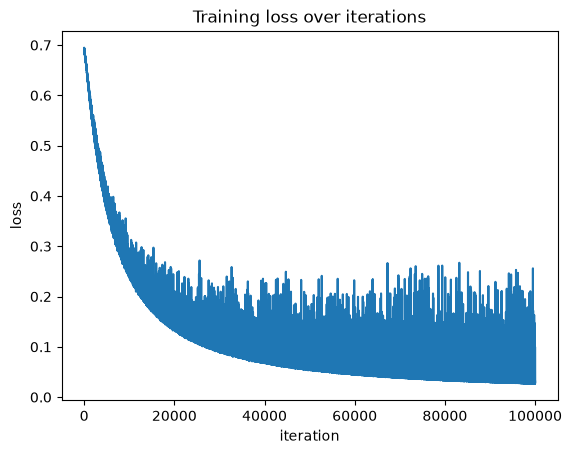

In [11]:
import matplotlib.pyplot as plt

plt.plot(Ls)
plt.xlabel("iteration")
plt.ylabel("loss")
plt.title("Training loss over iterations")
plt.savefig("loss_curve.png", dpi=150, bbox_inches='tight')
plt.show()

## Evaluate accuracy

In [12]:
X_train, y_train, X_test, y_test = load_data("twitter_data.pkl")

train_preds = (predict_nn(X_train, W1, b1, W2, b2) > 0.5).astype(int).flatten()
test_preds  = (predict_nn(X_test,  W1, b1, W2, b2) > 0.5).astype(int).flatten()

print(f"Train accuracy: {(train_preds == y_train.flatten()).mean():.4f}")
print(f"Test accuracy:  {(test_preds  == y_test.flatten()).mean():.4f}")

Train accuracy: 0.9961
Test accuracy:  0.9970


## Save model for submission

In [13]:
with open("assignment2.pkl", "wb") as f:
  pickle.dump({"W1": W1, "b1": b1, "W2": W2, "b2": b2, "Ls": Ls}, f)
print("Saved assignment2.pkl")

Saved assignment2.pkl


## Sample predictions

In [22]:
with open("twitter_data.pkl", "rb") as f:
  data = pickle.load(f)
freqs = data['freqs']

from utils import extract_features

sample_tweets = [
  "I had an amazing day! Everything went perfectly.",
  "This dish is pushing the boundaries of what counts as food!",
  "The weather is nice today :)",
  "I'm so disappointed with the service, worst experience ever.",
  "This is a wicked movie. The plot was terrible and I was sad until the ending!",
]

for tweet in sample_tweets:
  features = extract_features(tweet, freqs).reshape(-1, 1)   # (3, 1)
  y_hat = inference_2layers(features, W1, W2, b1, b2)
  sentiment = "Positive" if y_hat > 0.5 else "Negative"
  print(f"Tweet: {tweet}")
  print(f"ŷ: {y_hat.item():.4f} | Sentiment: {sentiment}\n")

Tweet: I had an amazing day! Everything went perfectly.
ŷ: 0.9384 | Sentiment: Positive

Tweet: This dish is pushing the boundaries of what counts as food!
ŷ: 0.2845 | Sentiment: Negative

Tweet: The weather is nice today :)
ŷ: 0.9698 | Sentiment: Positive

Tweet: I'm so disappointed with the service, worst experience ever.
ŷ: 0.1458 | Sentiment: Negative

Tweet: This is a wicked movie. The plot was terrible and I was sad until the ending!
ŷ: 0.0248 | Sentiment: Negative

